diferentes taxas de acerto pros comentarios filhos
DISCORDAR pode significar muitas coisas, cuidado

features: rotulo anterior: entrar ou não

começar fazendo por simplicidade: rotulo anterior foi dado (gabarito), depois ir pra tabela
segundo problema: class hierarquica acumularia mais erros ainda. Talvez seria melhor fazer por 3 classes (concroda, discorda, neutro)

Abordagem:
Usar LLMs com embeddings e utilizar algoritmos de classificação tradicionais.

In [2]:
# imports
import pandas as pd # manipulação do dataset
import matplotlib.pyplot as plt 
import seaborn as sns   # visualização dataset
import networkx as nx   # grafos
import pygraphviz as pgv    # visualização de grafos

# Análise Exploratória do dataset bruto

In [3]:
# importação do dataset de treinamento
df = pd.read_csv('Dados/conjuntoDeDados_teste_grau_distancia.tsv', sep='\t', decimal = ',', encoding = 'UTF-8')
print(df.columns)
df.tail()

Index(['target_id', 'target_message', 'id', 'parent_id', 'author',
       'parent_name', 'parent_message', 'message', 'parent_label',
       'target_parent_message', 'target_and_message', 'label',
       'grau_distancia'],
      dtype='object')


,target_id,target_message,id,parent_id,author,parent_name,parent_message,message,parent_label,target_parent_message,target_and_message,label,grau_distancia
447,249,Com toda essa discussão sobre as regras do pix...,m6n8401,m6n3kc8,Anthony_Griffin,Robert_Wong,O correto seria o governo também criar um cana...,Mano vc esqueceu o /s,Discorda,Com toda essa discussão sobre as regras do pix...,Com toda essa discussão sobre as regras do pix...,Discorda,1.0
448,249,Com toda essa discussão sobre as regras do pix...,m6n8r12,m6n3kc8,Sheri_Fry,Robert_Wong,O correto seria o governo também criar um cana...,FUCKING AMBULANTES e comércios menores vão ter...,Discorda,Com toda essa discussão sobre as regras do pix...,Com toda essa discussão sobre as regras do pix...,Discorda,1.0
449,249,Com toda essa discussão sobre as regras do pix...,m6n6kpy,m6n3kc8,Christopher_Shaw,Robert_Wong,O correto seria o governo também criar um cana...,Só se mudar a legislação. Eles não são obrigad...,Discorda,Com toda essa discussão sobre as regras do pix...,Com toda essa discussão sobre as regras do pix...,Discorda,1.0
450,249,Com toda essa discussão sobre as regras do pix...,m6oa15g,m6n3kc8,Sheila_Bishop,Robert_Wong,O correto seria o governo também criar um cana...,[removed],Discorda,Com toda essa discussão sobre as regras do pix...,Com toda essa discussão sobre as regras do pix...,Irrelevante,1.0
451,249,Com toda essa discussão sobre as regras do pix...,m6od553,m6oa15g,Amber_Lyons,Sheila_Bishop,[removed],Sua mensagem foi removida devido a não adequaç...,Irrelevante,Com toda essa discussão sobre as regras do pix...,Com toda essa discussão sobre as regras do pix...,Irrelevante,2.0


Descrição das colunas:
- 'id', 'message', 'label', 'author' -> comentário atual avaliado
- 'target_id' -> id relativo ao coment original. Os demais ids em colunas são de comentários em relação a este.
- 'target_message' -> Alvo; mensagem que avalia-se o posicionamento.
- 'parent_name', 'parent_message', 'parent_label' -> comentário anterior, cujo atual responde
- 'target_and_message' -> mensagem alvo # comentário atual
- 'target_parent_message' -> mensagem alvo # parent # comentário atual

(*) Linha com id "Alvo" = descrição feita manualmente que sitetiza o pensamento do comentário Alvo.

### Labels

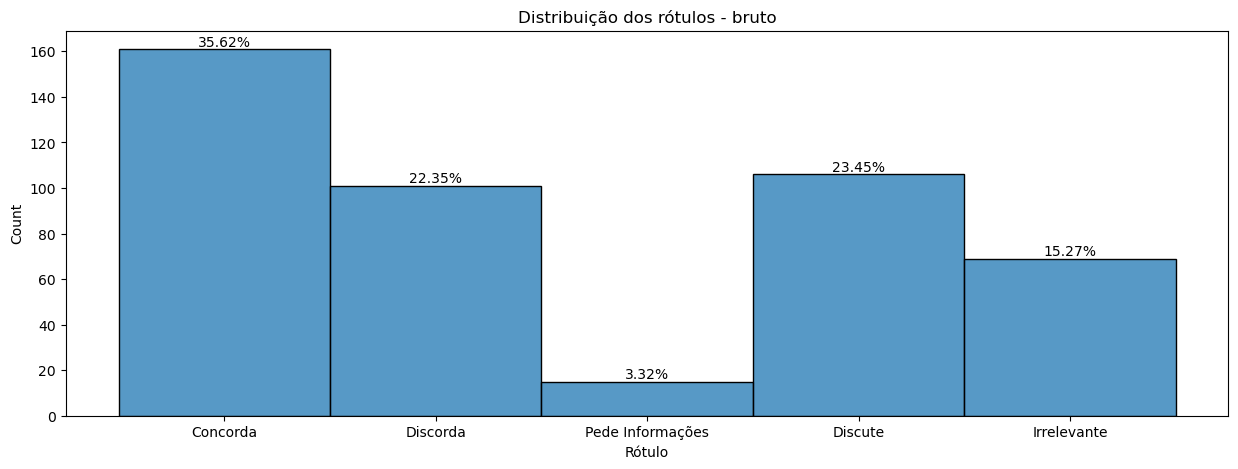

In [4]:
# Distribuição dos rótulos
plt.figure(figsize=(15, 5))
sns.histplot(x='label', data=df)
plt.title('Distribuição dos rótulos - bruto')
plt.xlabel('Rótulo')

# colocar label nas "barras" como porcentagem
total = len(df)
for p in plt.gca().patches:
    percentage = f'{p.get_height() / total:.2%}'
    plt.text(p.get_x() + p.get_width() / 2, p.get_height(), percentage, ha='center', va='bottom')

Utilizarei as classes: Concorda, Discorda, Neutro (Discute, Irrelevante ou Pede informações).

Text(0.5, 1.0, 'Distribuição dos rótulos')

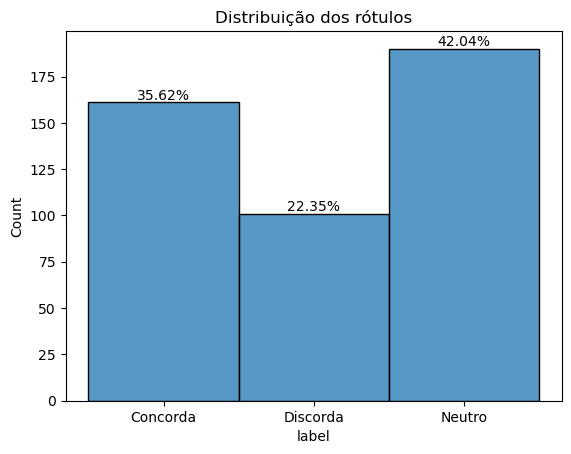

In [5]:
df_n = df.copy()

# desconsiderar linhas de "Alvo" para análise de distribuição (contem apenas mensagem de apoio)
df_n = df_n[df_n['id'] != 'Alvo']

# juntar labels "Neutro"
df_n['label'] = df_n['label'].replace('Discute', 'Neutro').replace('Pede Informações', 'Neutro').replace('Irrelevante', 'Neutro')

sns.histplot(x='label', data=df_n)
# colocar label nas "barras" como porcentagem
total = len(df_n)
for p in plt.gca().patches:
    percentage = f'{p.get_height() / total:.2%}'
    plt.text(p.get_x() + p.get_width() / 2, p.get_height(), percentage, ha='center', va='bottom')
plt.title('Distribuição dos rótulos')

# nota: o gráfico gerado já está com os rótulos "Comentário Original" corrigidos na seção posterior.

### Valores nulos

In [6]:
# checagem de valores nulos
print(df.isnull().sum())

target_id                 0
target_message            0
id                        0
parent_id                 0
author                    0
parent_name               0
parent_message           19
message                   0
parent_label              0
target_parent_message     0
target_and_message        0
label                     0
grau_distancia           62
dtype: int64


In [7]:
df['target_id'].unique()  # id do postagem original (alvo)
# mesma quantidade de parent_id nulos

array([195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207,
       208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220,
       221, 222, 223, 224, 225, 226, 227, 228, 229, 230, 231, 232, 233,
       234, 235, 236, 237, 238, 239, 240, 241, 242, 243, 244, 245, 246,
       247, 248, 249])

In [8]:
# 30 linhas sem label
sem_label = df[df['label'].isnull()]

# são referentes ao comentário original (id = 1)
print(len(sem_label[sem_label['id'] == '1']))
# quantas linhas com id = 1?
print(len(df[df['id'] == '1']))

# RESOLVIDO NO DATASET FINAL - Problema: apenas metade das linhas consideram a label do (id = 1) como "Comentário Original".

0
0


In [9]:
# Linhas onde parent_label é nulo mas parent_message não é, são filhos dos comentarios originais, que não possuem label.
df[df['parent_label'].isnull() & df['parent_message'].notnull()].value_counts()
# Problema foi resolvido

Series([], Name: count, dtype: int64)

### Visualização em Grafo

In [10]:
def criar_grafo(df):
    # Crie um grafo direcionado
    G = nx.DiGraph()

    # Adicione nós (comentários)
    for idx, row in df.iterrows():
        G.add_node(row['id'])

    # Adicione arestas de parent (resposta)
    for idx, row in df.iterrows():
        if pd.notnull(row['parent_id']):
            G.add_edge(row['parent_id'], row['id'], relation='parent')

    return G

G = criar_grafo(df)

In [11]:
# Visualização hierárquica (top-down)
def visualizar_grafo(G, titulo='Grafo de comentários'):
    plt.figure(figsize=(12, 8))
    pos = nx.nx_agraph.graphviz_layout(G, prog='dot')  # ou: nx.nx_pydot.graphviz_layout(G, prog='dot')
    nx.draw(G, pos, with_labels=True, node_size=500, font_size=8, arrows=True)
    plt.title(titulo)  # Set the title here
    plt.show()

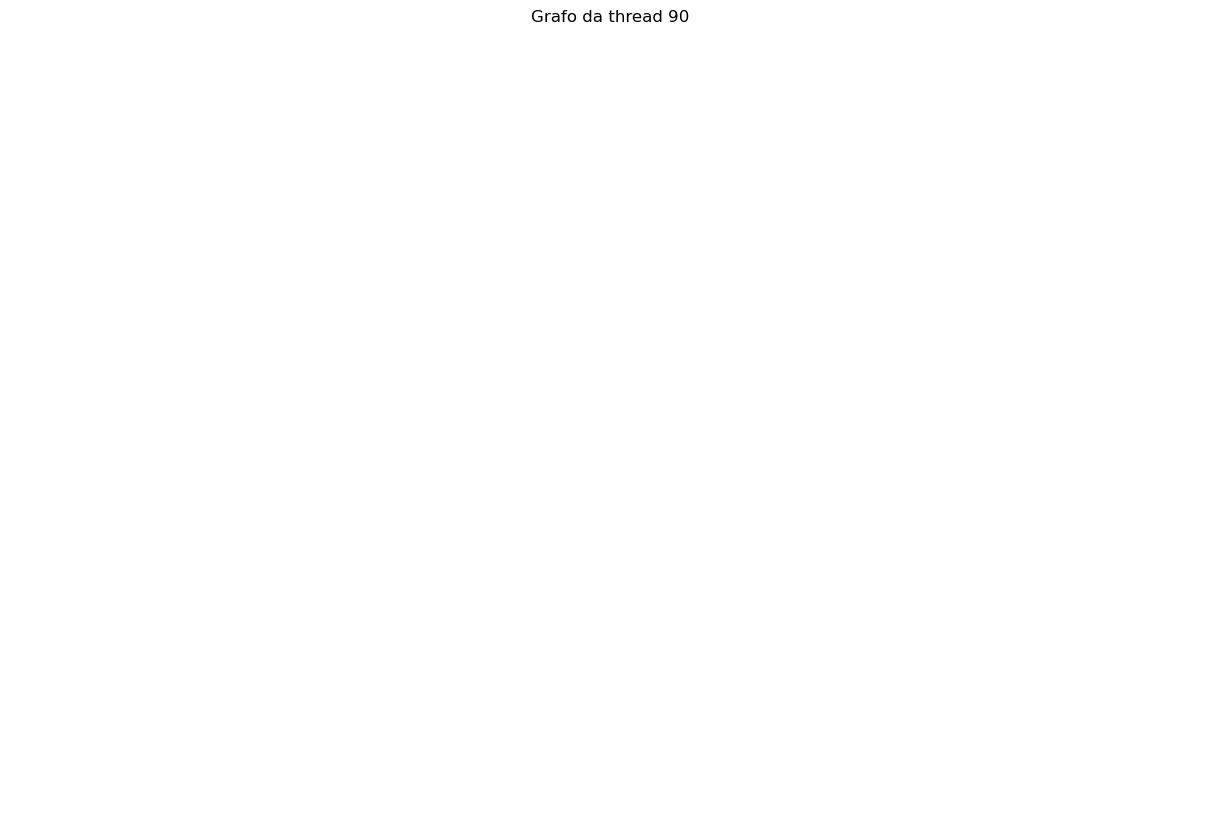

In [12]:
# df de uma thread específica
thread_id = 90
df_postagem = df[df['target_id'] == thread_id]  # target_id é o id da thread. Os demais ids em colunas são de comentários em relação a esta.

G_postagem = criar_grafo(df_postagem)
visualizar_grafo(G_postagem, titulo='Grafo da thread ' + str(thread_id))

In [13]:
df[df['id'] == '15h8cpw'].value_counts()  # 0

Series([], Name: count, dtype: int64)

## Conclusões

- O primeiro node representa a postagem, que não nos é relevante (e não está presente).
- Preciso prever as labels de cima pra baixo, a partir do comentário original.
- Parece que os comentários originais têm a parent_label como "Alvo da Conversa", posso usar para localizá-los
    -> e parent_name = 'Raiz'
- Os arquivos Conjunto_de_dados_treinamento/teste estão dispostos de forma diferente que neste aqui. 